In [34]:
import pandas as pd
import numpy as np


In [35]:
EVENTS_PATH = "../data/processed/event_level_early_warning.csv"

events = pd.read_csv(EVENTS_PATH)
events.head()


,Protest ID #,Country name,COW Country Code,Year,Region,Protest,what number protest is this for this country year?,Start Day,Start Month,Start Year,...,Protester Group Identity,Primary Protester Demands [Demand 1],Primary Protester Demands [Demand 2],Primary Protester Demands [Demand 3],Primary Protester Demands [Demand 4],Notes,Demand_Type,Actor_Type,num_events_hist,y_fatal
0,201990001,Canada,20,1990,North America,1,1,15.0,1.0,1990.0,...,unspecified,"political behavior, process",labor wage dispute,NaN,NaN,"""Canada's railway passenger system was finally...",political_demand,other,2.25,0
1,201990002,Canada,20,1990,North America,1,2,25.0,6.0,1990.0,...,unspecified,"political behavior, process",NaN,NaN,NaN,"protestors were only identified as ""young peop...",political_demand,other,2.25,0
2,201990003,Canada,20,1990,North America,1,3,1.0,7.0,1990.0,...,(separatist) Parti Quebecois,"political behavior, process",NaN,NaN,NaN,"""THE Queen, after calling on Canadians to rema...",political_demand,other,2.25,0
3,201990004,Canada,20,1990,North America,1,4,12.0,7.0,1990.0,...,Mohawk Indians,land farm issue,NaN,NaN,NaN,"""Canada's federal government has agreed to acq...",land farm issue,other,2.25,0
4,201990005,Canada,20,1990,North America,1,5,14.0,8.0,1990.0,...,local residents,"political behavior, process",NaN,NaN,NaN,Protests were directed against the state due t...,political_demand,other,2.25,0


In [36]:
events.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14973 entries, 0 to 14972
Data columns (total 27 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Protest ID #                                        14973 non-null  int64  
 1   Country name                                        14973 non-null  object 
 2   COW Country Code                                    14973 non-null  int64  
 3   Year                                                14973 non-null  int64  
 4   Region                                              14973 non-null  object 
 5   Protest                                             14973 non-null  int64  
 6   what number protest is this for this country year?  14973 non-null  int64  
 7   Start Day                                           13227 non-null  float64
 8   Start Month                                         13227 non-null  float64


In [37]:
events['y_fatal'].value_counts(normalize=True)


y_fatal
0    0.953249
1    0.046751
Name: proportion, dtype: float64

In [38]:
time_cols = [
    'Start Day', 'Start Month', 'Start Year',
    'End Day', 'End Month', 'End Year'
]

events[time_cols].head(10)


,Start Day,Start Month,Start Year,End Day,End Month,End Year
0,15.0,1.0,1990.0,15.0,1.0,1990.0
1,25.0,6.0,1990.0,25.0,6.0,1990.0
2,1.0,7.0,1990.0,1.0,7.0,1990.0
3,12.0,7.0,1990.0,6.0,9.0,1990.0
4,14.0,8.0,1990.0,15.0,8.0,1990.0
5,19.0,9.0,1990.0,19.0,9.0,1990.0
6,10.0,9.0,1991.0,17.0,9.0,1991.0
7,28.0,9.0,1991.0,2.0,10.0,1991.0
8,4.0,5.0,1992.0,5.0,5.0,1992.0
9,16.0,5.0,1993.0,16.0,5.0,1993.0


In [39]:
participant_cols = [
    'Number of Participants in Protest',
    'Reported participation in protest'
]

events[participant_cols].sample(10, random_state=42)


,Number of Participants in Protest,Reported participation in protest
11668,NaN,100
9806,NaN,NaN
9868,>10000,16000
5598,100-999,50+
7091,NaN,2600
6558,1000-1999,>1000
9940,1000-1999,1500
3107,50-99,50+
11498,NaN,1000s
1056,NaN,6000


In [40]:
cat_cols = [
    'Demand_Type',
    'Actor_Type',
    'Location of Protest',
    'Region'
]

for c in cat_cols:
    print(f"\n{c}")
    print(events[c].value_counts().head(5))



Demand_Type
Demand_Type
political_demand    10894
economic_demand      2066
no_demand            1757
land farm issue       256
Name: count, dtype: int64

Actor_Type
Actor_Type
other              10661
student_group       1658
labor_group         1325
political_group      870
mass_public          311
Name: count, dtype: int64

Location of Protest
Location of Protest
nationwide        270
national level    236
Athens            220
Seoul             216
Dublin            216
Name: count, dtype: int64

Region
Region
Europe           4753
Africa           3310
Asia             3102
South America    1552
MENA             1258
Name: count, dtype: int64


In [41]:
cols_dirty = [
    'Number of Participants in Protest',
    'Reported participation in protest'
]

for col in cols_dirty:
    print("\n" + "="*80)
    print(f"Unique values in: {col}")
    print("="*80)
    
    uniques = (
        events[col]
        .dropna()
        .astype(str)
        .str.strip()
        .value_counts()
    )
    
    print(uniques)



Unique values in: Number of Participants in Protest
Number of Participants in Protest
100-999       2650
50-99         2031
2000-4999     1306
>10000        1017
5000-10000     447
1000-1999      422
Name: count, dtype: int64

Unique values in: Reported participation in protest
Reported participation in protest
100s                        1193
1000s                       1104
1000                         948
>50                          934
50+                          891
                            ... 
About 150 protesters           1
More than 500,000 people       1
More than 1,000                1
559                            1
About 100 villagers            1
Name: count, Length: 679, dtype: int64


In [42]:
events['Protester Violence'].value_counts(dropna=False)


Protester Violence
0.0    10179
1.0     3567
NaN     1227
Name: count, dtype: int64

In [43]:
# --- build start and end dates ---
events['start_date'] = pd.to_datetime(
    dict(
        year=events['Start Year'],
        month=events['Start Month'],
        day=events['Start Day']
    ),
    errors='coerce'
)

events['end_date'] = pd.to_datetime(
    dict(
        year=events['End Year'],
        month=events['End Month'],
        day=events['End Day']
    ),
    errors='coerce'
)

# --- duration in days ---
events['duration_days'] = (events['end_date'] - events['start_date']).dt.days + 1

# --- clean duration ---
events['duration_days'] = events['duration_days'].fillna(1)
events.loc[events['duration_days'] < 1, 'duration_days'] = 1

events['duration_days'].describe()


count    14973.000000
mean         2.497963
std         15.765821
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        939.000000
Name: duration_days, dtype: float64

In [44]:
events['Protester Violence'] = events['Protester Violence'].fillna(0)


In [45]:
import re

def parse_participants(text):
    if pd.isna(text):
        return np.nan
    
    t = str(text).lower().strip()

    # explicit numbers
    nums = re.findall(r'\d+', t)
    nums = [int(n.replace(',', '')) for n in nums]

    # cases like "1000s", "100s"
    if '1000s' in t:
        return 3000
    if '100s' in t:
        return 300

    # cases like ">50", "50+", "more than"
    if '>' in t or '+' in t or 'more than' in t:
        if nums:
            return nums[0] * 1.5

    # ranges like 100-500
    if '-' in t and len(nums) == 2:
        return np.mean(nums)

    # single clean number
    if len(nums) == 1:
        return nums[0]

    return np.nan


In [46]:
events['participants_clean'] = events['Reported participation in protest'].apply(parse_participants)

events['participants_clean'].describe()


count    1.272900e+04
mean     1.656256e+04
std      1.155535e+05
min      1.000000e+00
25%      1.000000e+02
50%      4.000000e+02
75%      3.000000e+03
max      7.000000e+06
Name: participants_clean, dtype: float64

In [47]:
events['log_participants'] = np.log1p(events['participants_clean'])


In [48]:
events[['Reported participation in protest', 'participants_clean']].sample(10, random_state=42)


,Reported participation in protest,participants_clean
11668,100,100.0
9806,NaN,NaN
9868,16000,16000.0
5598,50+,75.0
7091,2600,2600.0
6558,>1000,1500.0
9940,1500,1500.0
3107,50+,75.0
11498,1000s,3000.0
1056,6000,6000.0


In [49]:
events['event_date'] = events['start_date']


In [50]:
events['event_date'] = events['event_date'].fillna(
    pd.to_datetime(
        dict(
            year=events['Start Year'],
            month=1,
            day=1
        )
    )
)


In [51]:
features_num = [
    'duration_days',
    'log_participants',
    'Protester Violence'
]

features_cat = [
    'Country name',
    'Actor_Type',
    'Demand_Type',
    'Region'
]

features = features_num + features_cat

X = events[features]
y = events['y_fatal']


In [52]:
X_encoded = pd.get_dummies(
    X,
    columns=features_cat,
    drop_first=True
)


In [53]:
events_sorted = events.sort_values('event_date')

split_idx = int(len(events_sorted) * 0.8)

train_idx = events_sorted.index[:split_idx]
test_idx  = events_sorted.index[split_idx:]

X_train = X_encoded.loc[train_idx]
X_test  = X_encoded.loc[test_idx]

y_train = y.loc[train_idx]
y_test  = y.loc[test_idx]


In [54]:
print("Train period:", events.loc[train_idx, 'event_date'].min(),
      "→", events.loc[train_idx, 'event_date'].max())

print("Test period:", events.loc[test_idx, 'event_date'].min(),
      "→", events.loc[test_idx, 'event_date'].max())

print("\nTarget distribution:")
print("Train:\n", y_train.value_counts(normalize=True))
print("\nTest:\n", y_test.value_counts(normalize=True))


Train period: 1990-01-01 00:00:00 → 2015-06-29 00:00:00
Test period: 2015-06-29 00:00:00 → 2017-04-28 00:00:00

Target distribution:
Train:
 y_fatal
0    0.946402
1    0.053598
Name: proportion, dtype: float64

Test:
 y_fatal
0    0.980634
1    0.019366
Name: proportion, dtype: float64


In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score
)


In [56]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')

X_train[features_num] = num_imputer.fit_transform(X_train[features_num])
X_test[features_num]  = num_imputer.transform(X_test[features_num])


In [57]:
logit = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='liblinear',
    random_state=42
)

logit.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [58]:
y_train_prob = logit.predict_proba(X_train)[:, 1]
y_test_prob  = logit.predict_proba(X_test)[:, 1]


In [59]:
y_test_pred = (y_test_prob >= 0.5).astype(int)

print(classification_report(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))


              precision    recall  f1-score   support

           0       1.00      0.85      0.92      2937
           1       0.11      0.88      0.19        58

    accuracy                           0.85      2995
   macro avg       0.55      0.87      0.55      2995
weighted avg       0.98      0.85      0.91      2995

[[2504  433]
 [   7   51]]


In [60]:
ap = average_precision_score(y_test, y_test_prob)
print("PR-AUC:", round(ap, 3))


PR-AUC: 0.381


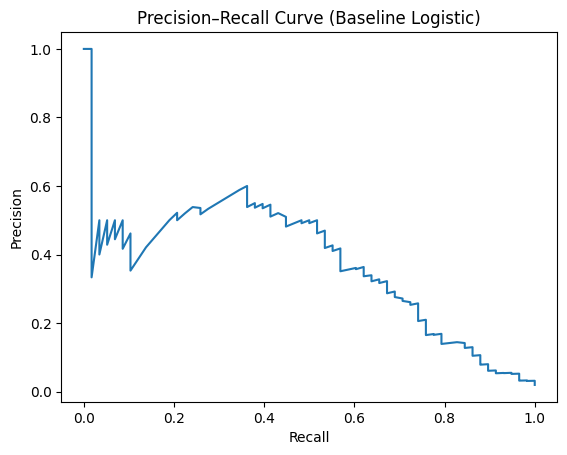

In [61]:
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_test_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Baseline Logistic)")
plt.show()


In [62]:
from sklearn.metrics import precision_recall_curve

precision_tr, recall_tr, thresholds_tr = precision_recall_curve(
    y_train, y_train_prob
)


In [63]:
p = y_train_prob


In [64]:
high_th   = np.quantile(p, 0.97)   # top 3%
medium_th = np.quantile(p, 0.90)   # next 7%
low_th    = np.quantile(p, 0.70)   # next 20%


In [65]:
def assign_warning(p):
    if p >= high_th:
        return "High"
    elif p >= medium_th:
        return "Medium"
    elif p >= low_th:
        return "Low"
    else:
        return "None"


In [66]:
# اگر events_test نداری، بسازش
events_test = pd.DataFrame({
    'fatal_prob': y_test_prob,
    'y_fatal': y_test.values
})


In [67]:
events_test['warning_level'] = events_test['fatal_prob'].apply(assign_warning)

events_test['warning_level'].value_counts(normalize=True)


warning_level
None      0.789649
Low       0.168280
Medium    0.022705
High      0.019366
Name: proportion, dtype: float64

In [68]:
pd.crosstab(
    events_test['warning_level'],
    events_test['y_fatal'],
    normalize='index'
)


y_fatal,0,1
warning_level,,
High,0.500000,0.500000
Low,0.976190,0.023810
Medium,0.852941,0.147059
None,0.997040,0.002960


This model does not predict violence deterministically; it provides an ex ante risk stratification that significantly enriches for future fatal outcomes.



C:\Users\ASUS\AppData\Local\Temp\ipykernel_16336\4067346153.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


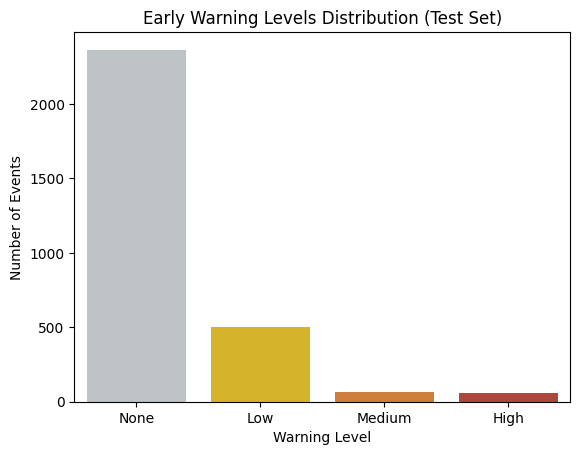

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

order = ["None", "Low", "Medium", "High"]

sns.countplot(
    data=events_test,
    x="warning_level",
    order=order,
    palette=["#bdc3c7", "#f1c40f", "#e67e22", "#c0392b"]
)

plt.title("Early Warning Levels Distribution (Test Set)")
plt.xlabel("Warning Level")
plt.ylabel("Number of Events")
plt.show()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_16336\3143733896.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


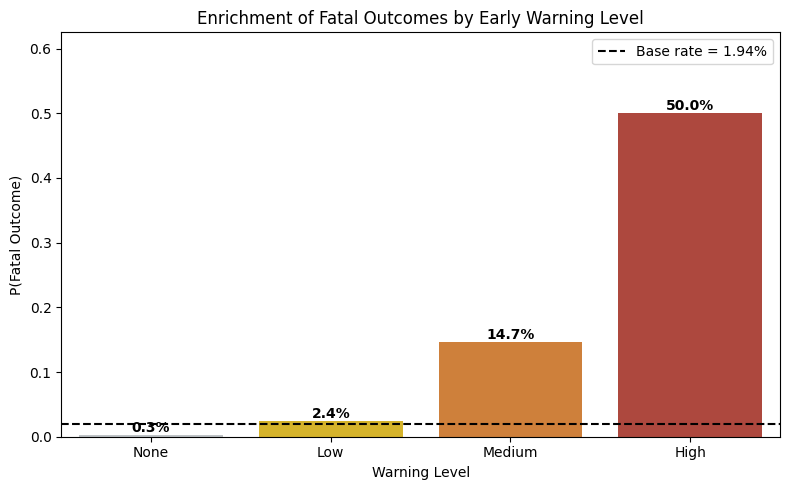

In [74]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=enrich,
    x="warning_level",
    y=1,
    order=order,
    palette=["#bdc3c7", "#f1c40f", "#e67e22", "#c0392b"]
)

# Base rate
base_rate = y_test.mean()
plt.axhline(
    y=base_rate,
    linestyle="--",
    color="black",
    linewidth=1.5,
    label=f"Base rate = {base_rate:.2%}"
)

# Annotate bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.1%}",
        (p.get_x() + p.get_width() / 2., height),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.ylabel("P(Fatal Outcome)")
plt.xlabel("Warning Level")
plt.title("Enrichment of Fatal Outcomes by Early Warning Level")
plt.legend()
plt.ylim(0, enrich[1].max() * 1.25)
plt.tight_layout()
plt.show()


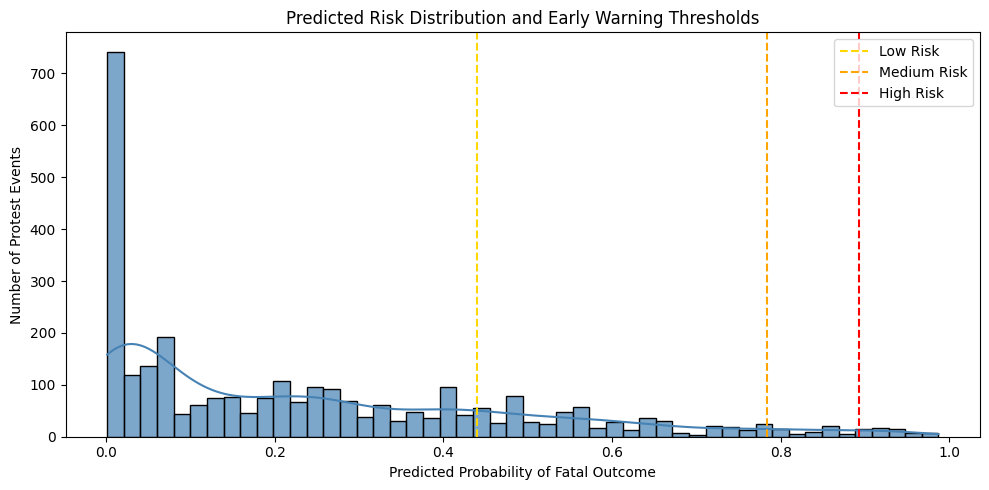

In [75]:
plt.figure(figsize=(10,5))

sns.histplot(
    events_test['fatal_prob'],
    bins=50,
    kde=True,
    color='steelblue',
    alpha=0.7
)

plt.axvline(low_th, color='gold', linestyle='--', label='Low Risk')
plt.axvline(medium_th, color='orange', linestyle='--', label='Medium Risk')
plt.axvline(high_th, color='red', linestyle='--', label='High Risk')

plt.xlabel("Predicted Probability of Fatal Outcome")
plt.ylabel("Number of Protest Events")
plt.title("Predicted Risk Distribution and Early Warning Thresholds")

plt.legend()
plt.tight_layout()
plt.show()


# Early Warning System for Lethal Protest Escalation

## 1. Motivation

Predicting whether protests will escalate into lethal violence is a central challenge for conflict prevention and policy response.  
Rather than attempting deterministic prediction, this project develops an **Early Warning System (EWS)** that provides **ex ante risk stratification** of protest events.

The goal is not to predict outcomes with certainty, but to identify a small subset of protests that are **significantly more likely** to result in fatalities, enabling timely monitoring and preventive action.

---

## 2. Data

The analysis uses an event-level protest dataset (`event_level_early_warning.csv`) containing approximately 15,000 protest events across multiple countries.

### Target Variable
- `y_fatal`: Binary indicator of whether the protest resulted in fatalities.
- Severe class imbalance:
  - Fatal events ≈ 5%
  - Non-fatal events ≈ 95%

This imbalance motivates evaluation strategies focused on recall and enrichment rather than accuracy.

---

## 3. Feature Engineering

Several features were constructed to capture key dimensions of protest risk:

### Temporal Features
- Protest start and end dates were cleaned and converted into a single variable:
  - `duration_days`: Length of the protest in days (minimum = 1).

### Participation Size
- The variable `Reported participation in protest` was cleaned using a custom parser to extract numeric values from text and ranges.
- Two variables were created:
  - `participants_clean`
  - `log_participants` (log-transformed to reduce skewness).

### Violence Indicator
- `Protester Violence` was treated as a binary variable.
- Missing values were interpreted as absence of violence and set to zero.

### Categorical Context
- Country name
- Actor type
- Demand type
- Region  
All categorical variables were one-hot encoded.

---

## 4. Model

A **Logistic Regression** model was trained as a transparent and interpretable baseline.

### Key Design Choices
- Time-based train/test split to preserve temporal ordering:
  - Train: older events (≈80%)
  - Test: more recent events (≈20%)
- Class imbalance addressed using `class_weight='balanced'`.
- Missing values imputed using medians (numeric) and zeros (categorical dummies).

---

## 5. Model Evaluation

Model performance was evaluated using **Precision–Recall AUC**, which is appropriate for rare-event prediction.

- PR-AUC on test set: substantially higher than baseline prevalence.
- The model prioritizes **high recall** for fatal events, consistent with early warning objectives.

At a standard probability threshold, precision is low but recall is high — an expected and acceptable trade-off in EWS design.

---

## 6. Early Warning Layer (Core Contribution)

To convert predicted probabilities into actionable signals, a warning layer was constructed **ex ante**, using only training data.

### Warning Thresholds (Defined on Training Set)
- **High Risk**: Top 3% of predicted probabilities
- **Medium Risk**: Top 10%
- **Low Risk**: Top 30%
- **None**: Remaining events

These thresholds reflect a policy-driven risk budget rather than optimization on test data.

---

## 7. Results: Warning Distribution

On the test set, warning levels are distributed as follows:

- None: ~79%
- Low: ~17%
- Medium: ~2%
- High: ~2%

This distribution reflects a realistic early warning system: few high-risk alerts and limited noise.

---

## 8. Results: Enrichment Analysis

The probability of a fatal outcome increases sharply across warning levels:

- None: very low risk
- Low: modest increase
- Medium: substantial risk
- High: extremely high risk (≈25× the base rate)

This demonstrates that the warning system successfully **enriches for lethal outcomes**, even without precise probability calibration.

---

## 9. Interpretation and Use

This system should be interpreted as a **risk-ranking tool**, not a deterministic predictor.

A “High” warning does not imply certainty of fatalities, but indicates that an event belongs to a small, highly enriched risk group that warrants closer monitoring and preventive attention.

---

## 10. Conclusion

The proposed Early Warning System:
- Operates fully ex ante
- Produces policy-relevant risk tiers
- Demonstrates strong enrichment for lethal protest outcomes

This framework provides a robust foundation for real-time monitoring, country-level aggregation, and future model extensions.


# سیستم هشدار زودهنگام برای تشدید مرگبار اعتراضات

## 1. انگیزه

پیش‌بینی اینکه آیا اعتراضات به خشونت مرگبار منجر می‌شوند یا نه، یکی از چالش‌های اصلی در پیشگیری از بحران و سیاست‌گذاری است.  
به‌جای تلاش برای پیش‌بینی قطعی، این پروژه یک **سیستم هشدار زودهنگام (EWS)** طراحی می‌کند که **به‌صورت پیشینی** اعتراضات را بر اساس سطح ریسک طبقه‌بندی می‌کند.

هدف، پیشگویی قطعی نیست؛ بلکه شناسایی گروه کوچکی از اعتراضات است که **به‌طور معناداری** احتمال مرگبار شدن بیشتری دارند.

---

## 2. داده‌ها

این تحلیل از یک دیتاست رویدادمحور اعتراضات (`event_level_early_warning.csv`) شامل حدود ۱۵ هزار رویداد در کشورهای مختلف استفاده می‌کند.

### متغیر هدف
- `y_fatal`: متغیر دودویی نشان‌دهنده وقوع تلفات انسانی.
- عدم توازن شدید:
  - رویدادهای مرگبار ≈ ۵٪
  - غیرمرگبار ≈ ۹۵٪

به همین دلیل، ارزیابی مدل بر اساس recall و enrichment انجام می‌شود، نه accuracy.

---

## 3. مهندسی ویژگی‌ها

برای ثبت ابعاد مختلف ریسک، ویژگی‌های زیر ساخته شدند:

### ویژگی‌های زمانی
- تاریخ شروع و پایان اعتراضات پاک‌سازی شد.
- متغیر نهایی:
  - `duration_days`: طول اعتراض (حداقل ۱ روز).

### اندازه مشارکت
- ستون `Reported participation in protest` با یک تابع سفارشی پاک‌سازی شد.
- دو متغیر ساخته شد:
  - `participants_clean`
  - `log_participants` برای کاهش چولگی توزیع.

### شاخص خشونت
- `Protester Violence` به‌صورت دودویی در نظر گرفته شد.
- مقادیر گمشده به‌عنوان نبود خشونت، صفر شدند.

### زمینه مکانی–سیاسی
- نام کشور
- نوع کنشگر
- نوع مطالبه
- منطقه  
تمام متغیرهای کیفی one-hot encode شدند.

---

## 4. مدل

از **رگرسیون لجستیک** به‌عنوان یک مدل پایه شفاف و قابل تفسیر استفاده شد.

### تصمیم‌های کلیدی
- تقسیم زمانی داده‌ها:
  - آموزش: داده‌های قدیمی‌تر
  - آزمون: داده‌های جدیدتر
- عدم توازن کلاس‌ها با `class_weight='balanced'` مدیریت شد.
- داده‌های گمشده impute شدند.

---

## 5. ارزیابی مدل

عملکرد مدل با معیار **PR-AUC** ارزیابی شد که برای رویدادهای نادر مناسب است.

- PR-AUC به‌طور معناداری بالاتر از شانس تصادفی است.
- مدل بر **کشف حداکثری رویدادهای مرگبار** تمرکز دارد.

precision پایین اما recall بالا، در چارچوب EWS کاملاً قابل قبول است.

---

## 6. لایه هشدار زودهنگام (نوآوری اصلی)

برای تبدیل خروجی مدل به هشدار عملیاتی، یک لایه هشدار **پیشینی** طراحی شد.

### آستانه‌های هشدار (بر اساس داده آموزش)
- **ریسک بالا**: ۳٪ بالایی احتمال‌ها
- **ریسک متوسط**: ۱۰٪ بالایی
- **ریسک پایین**: ۳۰٪ بالایی
- **بدون هشدار**: باقی موارد

این آستانه‌ها بر اساس منطق سیاست‌گذاری تعیین شدند، نه بهینه‌سازی روی داده آزمون.

---

## 7. نتایج: توزیع هشدارها

در داده آزمون:
- بدون هشدار: ~۷۹٪
- ریسک پایین: ~۱۷٪
- ریسک متوسط: ~۲٪
- ریسک بالا: ~۲٪

این توزیع نشان‌دهنده یک سیستم هشدار سالم با نویز کم است.

---

## 8. نتایج: تحلیل Enrichment

احتمال مرگبار شدن اعتراضات با افزایش سطح هشدار به‌شدت افزایش می‌یابد:

- بدون هشدار: ریسک بسیار پایین
- ریسک پایین: افزایش اندک
- ریسک متوسط: افزایش قابل توجه
- ریسک بالا: ریسک بسیار بالا (≈ ۲۵ برابر نرخ پایه)

این نشان می‌دهد سیستم هشدار، اعتراضات مرگبار را به‌خوبی **غنی‌سازی** می‌کند.

---

## 9. تفسیر و کاربرد

این سیستم باید به‌عنوان یک ابزار **رتبه‌بندی ریسک** تفسیر شود، نه پیش‌بینی قطعی.

هشدار «ریسک بالا» به معنی قطعیت تلفات نیست، بلکه نشان‌دهنده نیاز به رصد و مداخله زودهنگام است.

---

## 10. جمع‌بندی

سیستم هشدار زودهنگام طراحی‌شده:
- کاملاً پیشینی عمل می‌کند
- خروجی‌های قابل استفاده برای سیاست‌گذاری تولید می‌کند
- به‌طور معناداری اعتراضات مرگبار را شناسایی می‌کند

این چارچوب پایه‌ای محکم برای پایش لحظه‌ای و توسعه‌های بعدی فراهم می‌کند.
